# 02 · EDA — Distribución de Cartera por Producto (Superfinanciera)

**Base de datos:** 2 de 3 — Distribución de cartera por producto (Superintendencia Financiera de Colombia, SFC)
**Alcance:** 110.969 registros · 68 entidades · 32 productos · mensual 02/2015 → 12/2025
**Pregunta de negocio:** ¿Qué productos y entidades concentran el mayor riesgo de incumplimiento?

Este es el dataset principal: desglosa la cartera por **calificación de riesgo (A–E)**, saldos vigentes y vencidos por rangos de meses de mora, y número de clientes.

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, "..")
from src.utils.loaders import load_sfc, save_processed

plt.rcParams["figure.figsize"] = (10, 5)
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

In [2]:
df = load_sfc()
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"Entidades: {df['entidad'].nunique()} | Productos: {df['producto'].nunique()}")
print(f"Rango temporal: {df['fecha_corte'].min().date()} -> {df['fecha_corte'].max().date()}")
df.head()

Filas: 110969 | Columnas: 34
Entidades: 68 | Productos: 32
Rango temporal: 2015-01-31 -> 2026-06-30


,tipo_entidad,codigo_entidad,entidad,fecha_corte,unicap,producto,renglon,desc_renglon,saldo_total_cartera,saldo_vigente,...,riesgo_A_clientes,riesgo_A_saldo,riesgo_B_clientes,riesgo_B_saldo,riesgo_C_clientes,riesgo_C_saldo,riesgo_D_clientes,riesgo_D_saldo,riesgo_E_clientes,riesgo_E_saldo
0,1,12,Banco Gnb Sudameris,2015-01-31,1,CRÉDITO ROTATIVO,5,CRÉDITO ROTATIVO TOTAL,"37,651,351,298","34,981,440,061",...,6,"32,878,868,826",270,"1,835,206,170",142,"975,343,138",326,"1,368,695,340",69,"593,093,538"
1,1,6,Itaú Banco Itaú.,2015-01-31,1,CRÉDITO ROTATIVO,5,CRÉDITO ROTATIVO TOTAL,"476,766,070,943","453,506,953,109",...,44,"442,277,573,569",1,"13,043,155,083",951,"7,559,380,077",965,"8,135,341,560",671,"5,750,620,653"
2,1,9,Citibank,2015-01-31,1,CRÉDITO ROTATIVO,5,CRÉDITO ROTATIVO TOTAL,"826,852,228,377","782,016,598,064",...,125,"772,666,404,396",2,"11,740,703,689",1,"9,872,854,505",2,"14,111,818,486",2,"18,460,447,300"
3,1,23,Banco De Occidente,2015-01-31,1,CRÉDITO ROTATIVO,5,CRÉDITO ROTATIVO TOTAL,"108,451,564,795","104,345,665,139",...,10,"100,426,465,880",324,"2,920,771,751",207,"1,936,819,277",165,"1,623,502,258",144,"1,544,005,629"
4,1,57,Banco Pichincha S.A.,2015-01-31,1,CRÉDITO ROTATIVO,5,CRÉDITO ROTATIVO TOTAL,"209,307,777,744","196,907,738,953",...,92,"196,131,426,784",5,"6,541,005,114",2,"2,574,770,601",3,"3,677,977,262",160,"382,597,983"


## Limpieza y normalización de los datos

Este es el dataset más grande del proyecto y el que **más particularidades de formato** presenta. La limpieza vive centralizada en `src/utils/loaders.py` (función `load_sfc`); aquí la importamos, la explicamos y verificamos el resultado, comparando el crudo contra el limpio.

### 1. Contexto del dataset crudo

- **Fuente:** Superintendencia Financiera de Colombia (SFC / Superfinanciera) — serie estadística mensual *«Distribución de cartera por producto»*, publicada en su catálogo de datos abiertos.
- **Unidad observacional:** cada fila es una **entidad vigilada × producto de crédito × renglón × fecha de corte mensual** (02/2015 → 12/2025).
- **Tamaño crudo:** 110.969 filas de datos × 34 columnas (≈ 35 MB).
- Igual que la base 1 (*Comportamiento de Cartera y Crédito*), **todo llega como texto**; a diferencia de aquella, usa **otro formato numérico** — el contraste clave de la sección 3.

### 2. Lectura sin cabecera y nombres por posición

`load_sfc` lee el CSV con `header=None` y `skiprows=1`, y asigna los **34 nombres por posición** desde la lista `SFC_COLUMNS` de `loaders.py`. ¿Por qué descartar el encabezado original?

1. **No sirve como identificador:** la primera fila trae etiquetas descriptivas largas y numeradas — `'(1) Saldo de la cartera a la fecha de corte del reporte'`, `'(2) Vigente'`, `'(3) Vencida 1-2 Meses'`… — imposibles de usar como nombres de columna en código.
2. **Problemas de encoding entre descargas:** el encabezado del portal ha llegado con codificaciones inconsistentes entre una descarga y otra (la documentación previa del proyecto, AGENTS.md, registraba incluso separador `;` y `latin-1`, que este archivo no usa). Depender del encabezado hace la carga frágil.
3. **Determinismo:** mientras la SFC conserve el **orden** de las columnas, nombrar por posición garantiza siempre el mismo resultado.

La estructura de las 34 columnas se detalla en la sección 4.

In [3]:
from src.utils.loaders import RAW, SFC_COLUMNS

# Primeras 3 líneas del archivo tal cual: la fila 0 es el encabezado original
vistazo = pd.read_csv(RAW / "Distribución_de_cartera_por_producto_20260914.csv",
                      sep=",", encoding="utf-8", header=None, nrows=3, dtype=str)
vistazo.iloc[:3, :9]  # solo las primeras 9 columnas para que sean legibles

,0,1,2,3,4,5,6,7,8
0,TIPO_ENTIDAD,CODIGO_ENTIDAD,NOMBREENTIDAD,FECHA_CORTE,UNICAP,DESCRIP_UC,RENGLON,DESC_RENGLON,(1) Saldo de la cartera a la fecha de corte de...
1,1,12,Banco Gnb Sudameris,31/01/2015,1,CRÉDITO ROTATIVO,5,CRÉDITO ROTATIVO TOTAL,37.651.351.298
2,1,6,Itaú Banco Itaú.,31/01/2015,1,CRÉDITO ROTATIVO,5,CRÉDITO ROTATIVO TOTAL,"476.766.070.943,32"


### 3. Formato de montos: ¡distinto al de la base 1 (Comportamiento de Cartera y Crédito)!

**Contraste clave con la base 1 (*Comportamiento de Cartera y Crédito*).** Ambos publican pesos colombianos como texto, pero con convenciones **opuestas**:

| Dataset | Separador de miles | Separador decimal | Ejemplo crudo | Valor real (COP) |
|---------|--------------------|-------------------|---------------|------------------|
| Base 1 — Comportamiento de Cartera y Crédito | coma `,` | (no usa) | `'$ 14,629,091'` | 14 629 091 |
| **SFC** | **punto `.`** | **coma `,`** | `'37.651.351.298'` / `'32.878.868.825,55'` | 37 651 351 298 / 32 878 868 825,55 |

Si se aplicara el parser equivocado (`parse_monto_icetex`, que elimina comas), un valor como `'37.651.351.298'` no sería convertible y quedaría como `NaN` — se perdería **el 100 % de los saldos**. Por eso `loaders.py` define **dos parsers separados** (`parse_monto_icetex` y `parse_monto_sfc`: este borra puntos y convierte la coma en punto decimal) y lo documenta como *regla de oro* del proyecto.

Las fechas también difieren: aquí son texto `'31/01/2015'` y se parsean con formato explícito `'%d/%m/%Y'` — día/mes/año, sin depender de la configuración regional de la máquina.

In [4]:
# Demostración del contraste: parser correcto vs parser equivocado
from src.utils.loaders import parse_monto_sfc, parse_monto_icetex

pd.DataFrame({
    "texto crudo": ["37.651.351.298", "32.878.868.825,55", "31/01/2015"],
    "regla": ["parse_monto_sfc", "parse_monto_sfc", "to_datetime(format='%d/%m/%Y')"],
    "parser SFC (correcto)": [parse_monto_sfc("37.651.351.298"),
                              parse_monto_sfc("32.878.868.825,55"),
                              pd.to_datetime("31/01/2015", format="%d/%m/%Y")],
    "parser de la base 1 (equivocado)": [parse_monto_icetex("37.651.351.298"),
                                   parse_monto_icetex("32.878.868.825,55"), "-"],
})

,texto crudo,regla,parser SFC (correcto),parser de la base 1 (equivocado)
0,37.651.351.298,parse_monto_sfc,"37,651,351,298",NaN
1,"32.878.868.825,55",parse_monto_sfc,"32,878,868,826",NaN
2,31/01/2015,to_datetime(format='%d/%m/%Y'),2015-01-31 00:00:00,-


### 4. Estructura de las 34 columnas

`SFC_COLUMNS` agrupa las 34 posiciones en cuatro bloques:

| Bloque | Posiciones | Columnas | Parseo |
|--------|-----------|----------|--------|
| Identificación | 0–7 | `tipo_entidad`, `codigo_entidad`, `entidad`, `fecha_corte`, `unicap`, `producto`, `renglon`, `desc_renglon` | `fecha_corte` → `datetime` (`'%d/%m/%Y'`) |
| Saldos | 8–22 | `saldo_total_cartera`, `saldo_vigente` y cartera vencida por rangos de meses: `vencida_1_2_meses`, `vencida_2_3_meses`, `vencida_1_3_meses`, `vencida_3_4_meses`, `vencida_mas_4_meses`, `vencida_3_6_meses`, `vencida_mas_6_meses`, `vencida_1_4_meses`, `vencida_4_6_meses`, `vencida_6_12_meses`, `vencida_12_18_meses`, `vencida_mas_12_meses`, `vencida_mas_18_meses` | `parse_monto_sfc` |
| Mora | 23 | `clientes_mora_mas_30` | `parse_cantidad` |
| Calificación de riesgo A–E | 24–33 | `riesgo_A_clientes`, `riesgo_A_saldo`, …, `riesgo_E_clientes`, `riesgo_E_saldo` | saldo: `parse_monto_sfc`; clientes: `parse_cantidad` |

Dos aclaraciones importantes:

- **Los rangos de vencida se solapan:** `vencida_1_3_meses`, `vencida_3_6_meses`, `vencida_mas_4_meses`, `vencida_1_4_meses`, `vencida_mas_6_meses`, `vencida_mas_12_meses` son **agregados** de los tramos básicos (1-2, 2-3, 3-4, 4-6, 6-12, 12-18, >18). No deben sumarse todos entre sí: habría doble conteo.
- **La calificación A–E** es la escala de riesgo crediticio de la SFC (A = mejor calidad, E = peor); se reporta tanto en número de clientes como en saldo.

### 5. Verificación del resultado limpio

In [5]:
print("Dimensiones                :", df.shape)
print("Filas duplicadas           :", df.duplicated().sum())
print("Rango temporal             :", df["fecha_corte"].min().date(), "->", df["fecha_corte"].max().date())
nulos = df.isna().sum()
print("Valores nulos (total)      :", nulos.sum())
print("\nColumnas con nulos:")
nulos[nulos > 0]

Dimensiones                : (110969, 34)


Filas duplicadas           : 0
Rango temporal             : 2015-01-31 -> 2026-06-30
Valores nulos (total)      : 461

Columnas con nulos:


riesgo_A_clientes    460
riesgo_D_clientes      1
dtype: int64

#### Limitación conocida en los conteos de clientes

Los únicos nulos del dataset (461) están en columnas de **conteo de clientes**, y su origen revela una inconsistencia del crudo: la SFC publica los conteos **también con puntos de miles** (`'6.176'`, `'43.553'`, `'1.041.231'`), pero `parse_cantidad` fue diseñada para el formato de la base 1 (*Comportamiento de Cartera y Crédito*: comas de miles). Consecuencias:

- Con **un punto** (miles): `float()` lo interpreta como decimal — `'6.176'` → `6.176` en lugar de `6176` (**error silencioso**).
- Con **dos o más puntos** (millones): el valor no es convertible y queda como `NaN` — `'1.041.231'` → `NaN` (los 461 nulos).

Las columnas de **saldos** — que son las que alimentan los análisis y gráficas de este notebook — sí quedan correctamente parseadas con `parse_monto_sfc`. Corregir los conteos exige modificar `loaders.py` (donde la limpieza está centralizada a propósito); queda documentado como mejora pendiente del pipeline.

In [6]:
# ¿De dónde salen esos NaN? Comparación crudo vs limpio en conteos de clientes
crudo_full = pd.read_csv(RAW / "Distribución_de_cartera_por_producto_20260914.csv",
                         sep=",", encoding="utf-8", header=None, skiprows=1,
                         dtype=str, low_memory=False)
crudo_full.columns = SFC_COLUMNS

comparacion = pd.concat([
    crudo_full[["riesgo_A_clientes", "clientes_mora_mas_30"]].head(5).add_suffix(" (crudo)"),
    df[["riesgo_A_clientes", "clientes_mora_mas_30"]].head(5).add_suffix(" (limpio)"),
], axis=1)
display(comparacion.style.set_caption("Conteos: el punto de miles se lee como decimal"))

# Valores con dos o más puntos: no convertibles -> NaN
sin_convertir = crudo_full.loc[df["riesgo_A_clientes"].isna(), "riesgo_A_clientes"]
print("Ejemplos que quedan como NaN:", sin_convertir.head(3).tolist())
print("Total de celdas afectadas   :", int(df["riesgo_A_clientes"].isna().sum() + df["riesgo_D_clientes"].isna().sum()))

,riesgo_A_clientes (crudo),clientes_mora_mas_30 (crudo),riesgo_A_clientes (limpio),clientes_mora_mas_30 (limpio)
0,6.176,469,6.176000,469.000000
1,43.553,2.476,43.553000,2.476000
2,125.128,5.830,125.128000,5.830000
3,9.723,425,9.723000,425.000000
4,91.873,9.361,91.873000,9.361000


Ejemplos que quedan como NaN: ['1.504.592', '1.330.862', '1.501.697']
Total de celdas afectadas   : 461


In [7]:
# ANTES / DESPUÉS de los saldos (bloque correctamente parseado)
antes = crudo_full.iloc[:3, [2, 5, 8, 9, 25]]
antes.columns = ["entidad", "producto", "saldo_total_cartera", "saldo_vigente", "riesgo_A_saldo"]
despues = df.iloc[:3][["entidad", "producto", "saldo_total_cartera", "saldo_vigente", "riesgo_A_saldo"]]
display(antes.style.set_caption("ANTES · crudo (texto con puntos de miles)"))
display(despues.style.set_caption("DESPUÉS · limpio (float, COP)"))

,entidad,producto,saldo_total_cartera,saldo_vigente,riesgo_A_saldo
0,Banco Gnb Sudameris,CRÉDITO ROTATIVO,37.651.351.298,34.981.440.061,"32.878.868.825,55"
1,Itaú Banco Itaú.,CRÉDITO ROTATIVO,"476.766.070.943,32","453.506.953.108,61","442.277.573.569,18"
2,Citibank,CRÉDITO ROTATIVO,"826.852.228.376,59","782.016.598.063,64","772.666.404.396,07"


,entidad,producto,saldo_total_cartera,saldo_vigente,riesgo_A_saldo
0,Banco Gnb Sudameris,CRÉDITO ROTATIVO,37651351298.000000,34981440061.000000,32878868825.549999
1,Itaú Banco Itaú.,CRÉDITO ROTATIVO,476766070943.320007,453506953108.609985,442277573569.179993
2,Citibank,CRÉDITO ROTATIVO,826852228376.589966,782016598063.640015,772666404396.069946


In [8]:
# Sanity check: la suma de la cartera vencida por tramos básicos
# (los no solapados) no puede superar el saldo total de la cartera.
tramos_vencida = ["vencida_1_2_meses", "vencida_2_3_meses", "vencida_3_4_meses",
                  "vencida_4_6_meses", "vencida_6_12_meses", "vencida_12_18_meses",
                  "vencida_mas_18_meses"]

muestra = df.sample(5_000, random_state=42)
suma_vencida = muestra[tramos_vencida].sum(axis=1)
violaciones = int((suma_vencida > muestra["saldo_total_cartera"] + 1).sum())
print(f"Filas con suma de vencidas > saldo total: {violaciones} de {len(muestra)} "
      f"({violaciones / len(muestra):.2%})")

Filas con suma de vencidas > saldo total: 0 de 5000 (0.00%)


### 6. Conclusión de la limpieza

El DataFrame quedó con **110.969 filas × 34 columnas**: sin duplicados, `fecha_corte` tipada como `datetime` mensual, saldos como `float` en COP (con el parser correcto para el formato SFC) y nombres `snake_case` asignados por posición. La verificación detectó y documentó una **limitación conocida** en los conteos de clientes (puntos de miles leídos como decimales / NaN) que no afecta los análisis de saldos de este notebook. Sobre esta base corren las secciones siguientes y el archivo `data/processed/sfc_limpio.csv` que consume el dashboard.

In [9]:
print("Tipos de entidad:")
print(df["tipo_entidad"].value_counts().to_string())
print("\nProductos (32):")
print(sorted(df["producto"].unique()))

Tipos de entidad:
tipo_entidad
1     77823
4     18482
32    11381
22     3126
2       157

Productos (32):
['CARTERA COMERCIAL CONSTRUCCION', 'CARTERA COMERCIAL CORPORATIVO', 'CARTERA COMERCIAL EMPRESARIAL', 'CARTERA COMERCIAL FACTOTING', 'CARTERA COMERCIAL FINAN E INSTITUCIO', 'CARTERA COMERCIAL LEASING FINANCIERO', 'CARTERA COMERCIAL MICROEMPRESA', 'CARTERA COMERCIAL MONEDA EXTRANJERA', 'CARTERA COMERCIAL OFICIAL O GOBIERNO', 'CARTERA COMERCIAL PYMES', 'CONSUMO BAJO MONTO', 'CREDITOS DE CONSUMO PARA EMPLEADOS', 'CREDITOS DE VIVIENDA PARA EMPL NO VIS', 'CREDITOS DE VIVIENDA PARA EMPLEADOS VIS', 'CRÉDITO ROTATIVO', 'LEASING HABITACIONAL NO VIS PESOS', 'LEASING HABITACIONAL NO VIS UVR', 'LEASING HABITACIONAL VIS PESOS', 'LEASING HABITACIONAL VIS UVR', 'LIBRANZA', 'LIBRANZA VIVIENDA NO VIS', 'LIBRANZA VIVIENDA VIS', 'LIBRE INVERSIÓN', 'MICROCREDITOS < O IGUALES A 25 SMMLV', 'MICROCREDITOS > 25  Y HASTA 120 SMMLV', 'OTROS PORTAFOLIOS DE CONSUMO', 'TARJETAS DE CRÉDITO', 'VEHÍCULO', 'VIVIE

## Evolución de la cartera total del sistema financiero

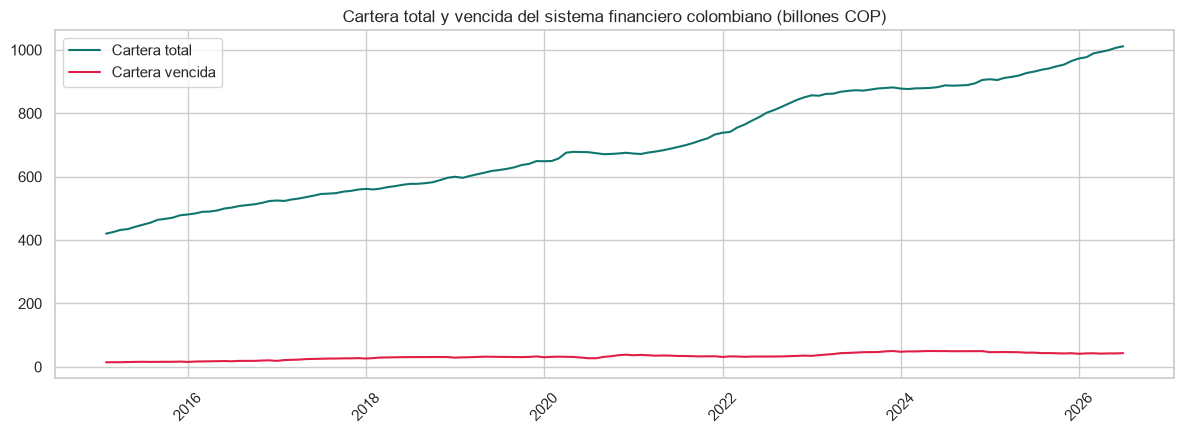

In [10]:
serie = df.groupby("fecha_corte")[["saldo_total_cartera", "saldo_vigente"]].sum().reset_index()
serie["vencida_total"] = serie["saldo_total_cartera"] - serie["saldo_vigente"]
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(serie["fecha_corte"], serie["saldo_total_cartera"] / 1e12, label="Cartera total", color="#0f766e")
ax.plot(serie["fecha_corte"], serie["vencida_total"] / 1e12, label="Cartera vencida", color="#e11d48")
ax.set_title("Cartera total y vencida del sistema financiero colombiano (billones COP)")
ax.legend(); ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

## Cartera por producto (último corte)

C:\Users\Admin\AppData\Local\Temp\ipykernel_42360\2992439377.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prod.head(15), x=prod["saldo_total_cartera"] / 1e9, y="producto", palette="viridis", ax=ax)


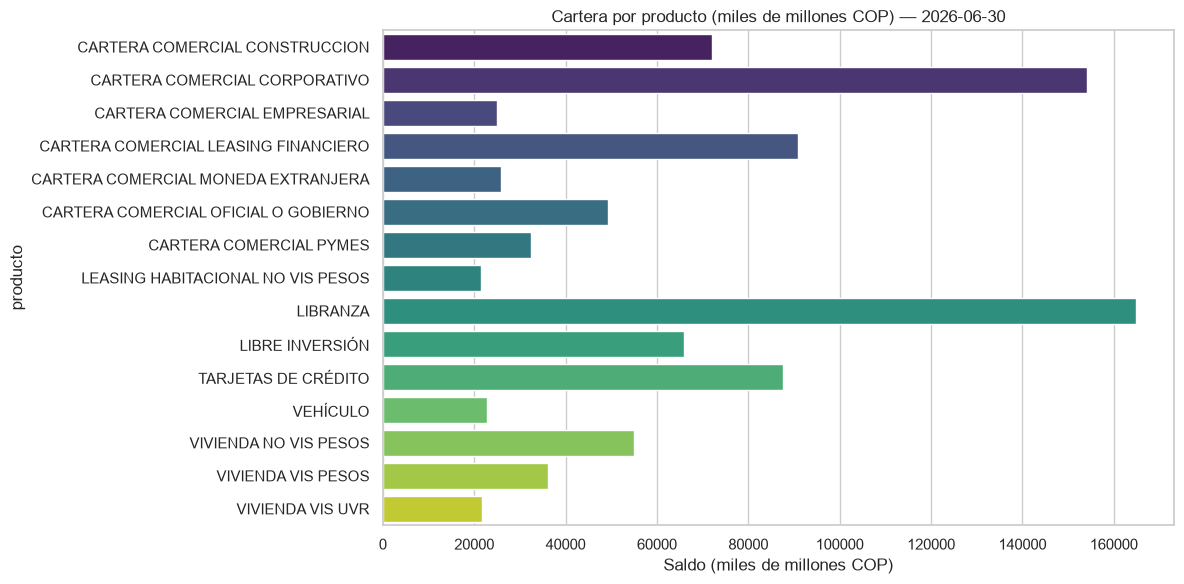

,producto,saldo_total_cartera,saldo_vigente,vencida,pct_vencida
19,LIBRANZA,"164,923,959,148,201","160,440,808,291,324","4,483,150,856,877",3
1,CARTERA COMERCIAL CORPORATIVO,"154,101,563,359,364","151,057,860,348,238","3,043,703,011,126",2
5,CARTERA COMERCIAL LEASING FINANCIERO,"90,822,789,322,436","87,334,626,206,850","3,488,163,115,586",4
26,TARJETAS DE CRÉDITO,"87,558,373,890,842","83,216,657,480,537","4,341,716,410,305",5
0,CARTERA COMERCIAL CONSTRUCCION,"72,060,002,114,119","68,204,414,212,544","3,855,587,901,575",5
22,LIBRE INVERSIÓN,"65,958,862,369,068","61,516,366,265,554","4,442,496,103,514",7
28,VIVIENDA NO VIS PESOS,"55,029,267,820,473","52,135,637,545,404","2,893,630,275,069",5
8,CARTERA COMERCIAL OFICIAL O GOBIERNO,"49,190,543,465,591","49,135,702,968,385","54,840,497,207",0
30,VIVIENDA VIS PESOS,"36,123,154,530,657","33,945,787,441,525","2,177,367,089,132",6
9,CARTERA COMERCIAL PYMES,"32,495,386,953,441","29,728,600,100,670","2,766,786,852,771",9


In [11]:
ultimo = df[df["fecha_corte"] == df["fecha_corte"].max()]
prod = ultimo.groupby("producto")[["saldo_total_cartera", "saldo_vigente"]].sum().reset_index()
prod["vencida"] = prod["saldo_total_cartera"] - prod["saldo_vigente"]
prod["pct_vencida"] = prod["vencida"] / prod["saldo_total_cartera"] * 100
prod = prod.sort_values("saldo_total_cartera", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=prod.head(15), x=prod["saldo_total_cartera"] / 1e9, y="producto", palette="viridis", ax=ax)
ax.set_title(f"Cartera por producto (miles de millones COP) — {ultimo['fecha_corte'].max().date()}")
ax.set_xlabel("Saldo (miles de millones COP)")
plt.tight_layout(); plt.show()
prod.head(15)

## Riesgo por producto: % de cartera vencida

C:\Users\Admin\AppData\Local\Temp\ipykernel_42360\801252987.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=prod.sort_values("pct_vencida", ascending=False).head(15),


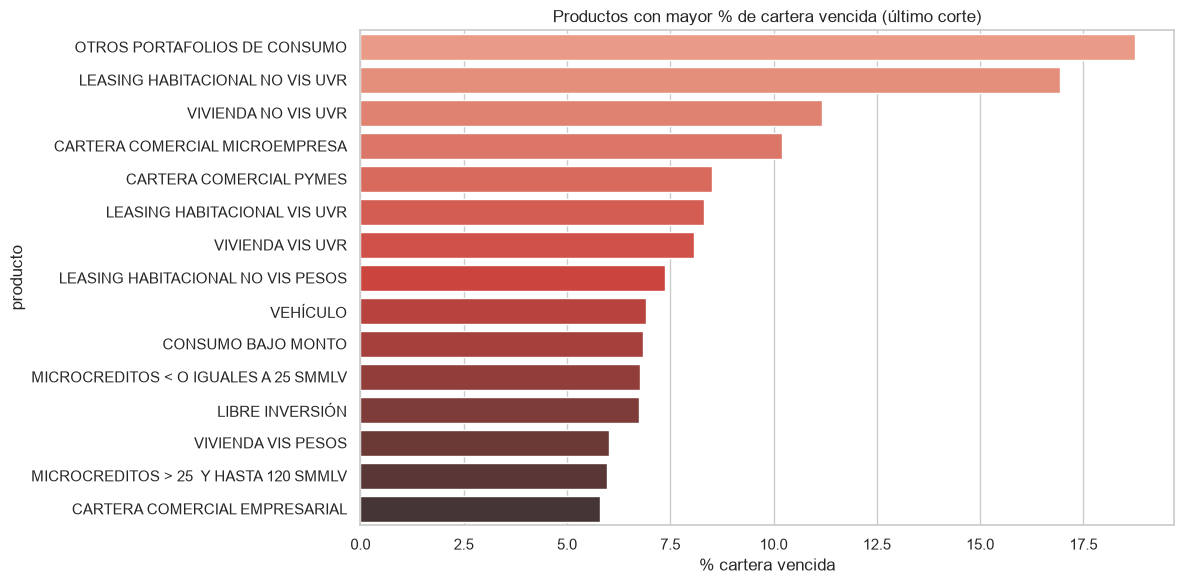

In [12]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=prod.sort_values("pct_vencida", ascending=False).head(15),
            x="pct_vencida", y="producto", palette="Reds_d", ax=ax)
ax.set_title("Productos con mayor % de cartera vencida (último corte)")
ax.set_xlabel("% cartera vencida")
plt.tight_layout(); plt.show()

## Calificación de riesgo (A–E): saldos y clientes

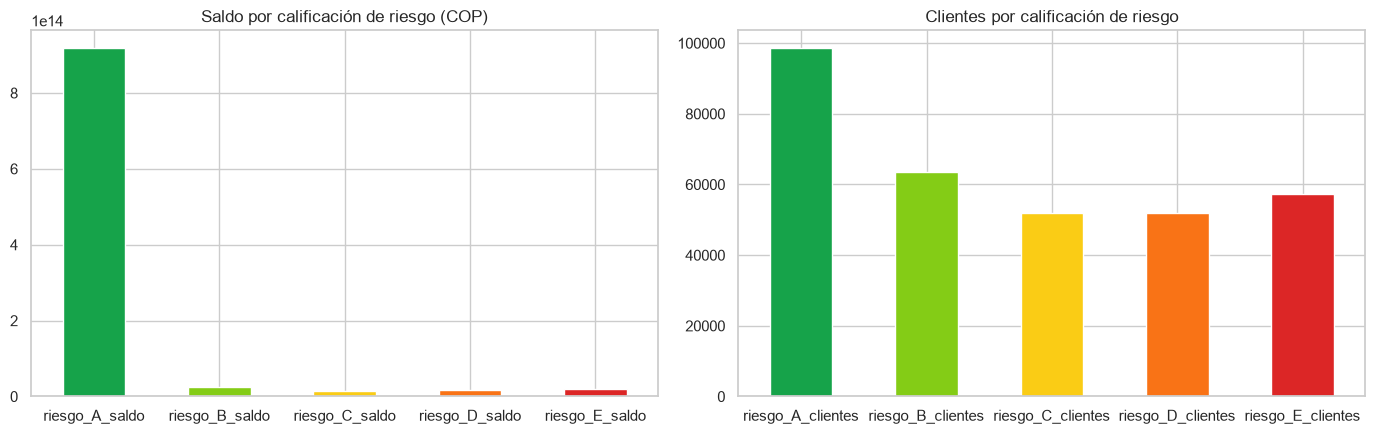

,saldo,clientes,% saldo,% clientes
riesgo_A_clientes,NaN,"98,652",NaN,30
riesgo_A_saldo,"918,717,211,302,522",NaN,92,NaN
riesgo_B_clientes,NaN,"63,613",NaN,20
riesgo_B_saldo,"25,848,098,297,685",NaN,3,NaN
riesgo_C_clientes,NaN,"51,988",NaN,16
riesgo_C_saldo,"14,977,216,680,932",NaN,2,NaN
riesgo_D_clientes,NaN,"52,057",NaN,16
riesgo_D_saldo,"18,170,317,055,599",NaN,2,NaN
riesgo_E_clientes,NaN,"57,245",NaN,18
riesgo_E_saldo,"20,174,351,344,237",NaN,2,NaN


In [13]:
riesgo = ultimo[["riesgo_A_saldo", "riesgo_B_saldo", "riesgo_C_saldo", "riesgo_D_saldo", "riesgo_E_saldo"]].sum()
riesgo_clientes = ultimo[["riesgo_A_clientes", "riesgo_B_clientes", "riesgo_C_clientes", "riesgo_D_clientes", "riesgo_E_clientes"]].sum()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
riesgo.plot(kind="bar", ax=ax[0], color=["#16a34a", "#84cc16", "#facc15", "#f97316", "#dc2626"])
ax[0].set_title("Saldo por calificación de riesgo (COP)")
ax[0].tick_params(axis="x", rotation=0)
riesgo_clientes.plot(kind="bar", ax=ax[1], color=["#16a34a", "#84cc16", "#facc15", "#f97316", "#dc2626"])
ax[1].set_title("Clientes por calificación de riesgo")
ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

tabla = pd.DataFrame({"saldo": riesgo, "clientes": riesgo_clientes})
tabla["% saldo"] = tabla["saldo"] / tabla["saldo"].sum() * 100
tabla["% clientes"] = tabla["clientes"] / tabla["clientes"].sum() * 100
tabla

## Entidades con mayor cartera vencida

C:\Users\Admin\AppData\Local\Temp\ipykernel_42360\4236021660.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ent.head(15), x=ent["vencida"] / 1e9, y="entidad", palette="Reds_d", ax=ax)


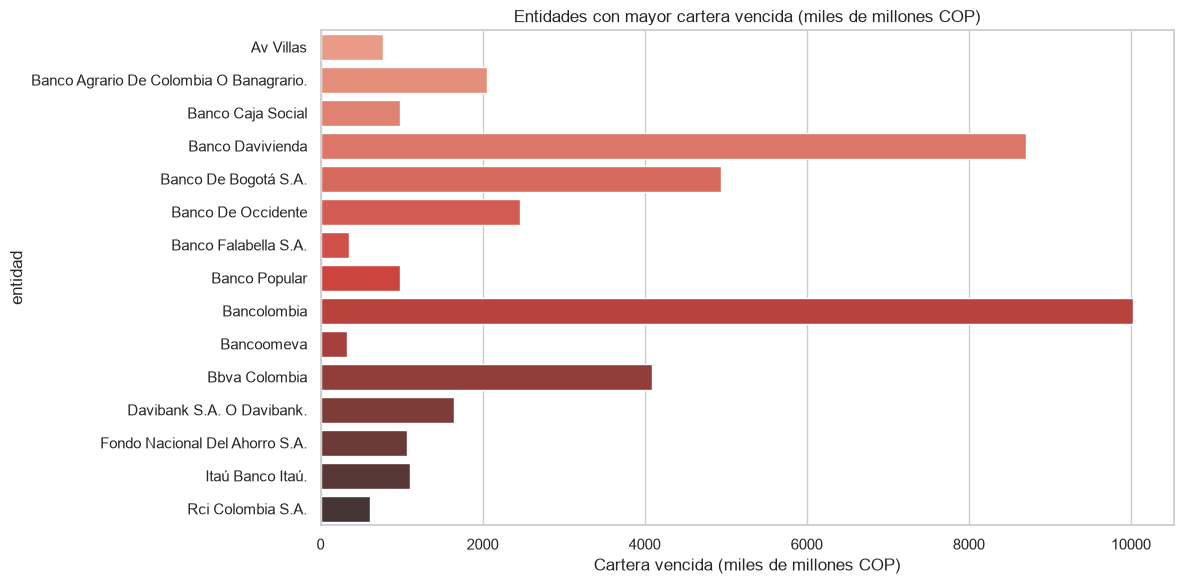

,entidad,saldo_total_cartera,saldo_vigente,vencida,pct_vencida
23,Bancolombia,"258,371,449,172,671","248,341,216,860,763","10,030,232,311,908",4
10,Banco Davivienda,"147,742,754,560,440","139,037,793,274,495","8,704,961,285,945",6
11,Banco De Bogotá S.A.,"116,723,633,028,692","111,777,521,760,069","4,946,111,268,624",4
25,Bbva Colombia,"106,848,697,197,060","102,756,330,649,139","4,092,366,547,921",4
12,Banco De Occidente,"70,893,519,734,561","68,437,669,384,457","2,455,850,350,104",3
6,Banco Agrario De Colombia O Banagrario.,"27,632,121,074,162","25,583,212,603,797","2,048,908,470,365",7
36,Davibank S.A. O Davibank.,"32,300,815,112,325","30,654,951,328,886","1,645,863,783,439",5
43,Itaú Banco Itaú.,"22,985,977,866,874","21,885,997,917,070","1,099,979,949,803",5
40,Fondo Nacional Del Ahorro S.A.,"14,671,001,108,215","13,601,499,270,444","1,069,501,837,771",7
8,Banco Caja Social,"23,604,096,895,883","22,620,679,451,956","983,417,443,927",4


In [14]:
ent = ultimo.groupby("entidad")[["saldo_total_cartera", "saldo_vigente"]].sum().reset_index()
ent["vencida"] = ent["saldo_total_cartera"] - ent["saldo_vigente"]
ent["pct_vencida"] = ent["vencida"] / ent["saldo_total_cartera"] * 100
ent = ent.sort_values("vencida", ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=ent.head(15), x=ent["vencida"] / 1e9, y="entidad", palette="Reds_d", ax=ax)
ax.set_title("Entidades con mayor cartera vencida (miles de millones COP)")
ax.set_xlabel("Cartera vencida (miles de millones COP)")
plt.tight_layout(); plt.show()
ent.head(15)

## Guardar datos limpios

In [15]:
out = save_processed(df, "sfc_limpio.csv")
print("Guardado en:", out)

Guardado en: C:\Users\Admin\Documents\UNIVERSIDAD\financiera, proyecto de Riesgo de Crédito\Financiera-proyecto-de-Riesgo-de-Cr-dito\data\processed\sfc_limpio.csv


### Hallazgos preliminares
- La cartera del sistema financiero crece de forma sostenida; la vencida acompaña el crecimiento.
- Los productos de mayor saldo (crédito rotativo, vivienda, consumo) concentran la exposición, pero el **% de cartera vencida** es mayor en productos como microcrédito y libranza.
- La calificación de riesgo A concentra la mayor parte de saldo y clientes; las calificaciones D y E (mayor riesgo) son minoritarias pero representan la pérdida esperada.